# Imports

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# DF Load

In [3]:
# Loading the data frame
df = pd.read_csv('/content/drive/MyDrive/phitronEvaluations/final-employee-ds.csv')
df

,EmployeeID,Name,Age,Gender,Department,ExperienceYears,Salary,WorkHoursPerWeek,PerformanceScore,JoinDate,Tshirt_size,ProjectCount,TrainingHours,DepartmentRating
0,101,Employee_1,50,Male,IT,17,86175.0,44,71,2010-01-10,L,2,4,1
1,102,Employee_2,36,Male,Finance,1,47805.0,44,68,2017-11-11,S,4,18,4
2,103,Employee_3,29,Male,Marketing,16,45237.0,44,69,2012-03-08,S,6,13,3
3,104,Employee_4,42,Male,Marketing,12,60056.0,48,76,2012-10-12,M,2,25,4
4,105,Employee_5,40,Female,Finance,19,85543.0,36,97,2014-12-30,XL,8,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,196,Employee_96,58,Female,Marketing,9,67350.0,47,65,2021-06-20,S,9,25,2
96,197,Employee_97,56,Male,IT,12,133008.0,45,77,2011-11-03,XL,5,12,2
97,198,Employee_98,43,Female,Management,1,134297.0,45,64,2015-05-24,M,3,39,3
98,199,Employee_99,48,Male,Marketing,1,65351.0,36,84,2021-05-19,L,5,17,2


# Question 1 solution

In [4]:
trainingHours = df['TrainingHours']
trainingHours

,TrainingHours
0,4
1,18
2,13
3,25
4,3
...,...
95,25
96,12
97,39
98,17


In [5]:
# transforming to numpy array with float data type
numpy_array = trainingHours.to_numpy(dtype=np.float64)
numpy_array

array([ 4., 18., 13., 25.,  3., 24., 44., 41., 24., 17., 39.,  7., 38.,
       39., 13., 31., 37., 32., 22., 14., 32., 24., 16., 32., 46.,  1.,
       13., 39., 39., 38.,  5.,  5.,  2.,  6.,  7., 41., 14., 46., 28.,
       32., 29., 38., 26., 35., 28., 37., 32., 36., 26., 32.,  3., 21.,
        1.,  9.,  4.,  9., 32., 37., 12., 30., 46., 35., 44., 23., 14.,
       28.,  7.,  4., 28., 46.,  3., 11., 44.,  1., 26., 30., 35., 35.,
       25., 42., 26.,  4., 19., 10.,  9., 39., 37.,  5.,  7., 22., 46.,
       25., 45., 42., 11., 25., 12., 39., 17., 24.])

In [6]:
mean = np.mean(numpy_array)
print(f"Mean: {mean}")

Mean: 24.19


In [7]:
std = np.std(numpy_array)
print(f"Standard Deviation: {std}")

Standard Deviation: 13.842467265628624


# Question 2 solution

In [8]:
# checking the total number of number values present within the series column
df['Salary'].isnull().sum()

np.int64(4)

In [9]:
# Calculating department wise salary median
deptSalary_median = df.groupby('Department')['Salary'].median()
deptSalary_median

,Salary
Department,
Finance,91991.0
HR,84078.0
IT,104272.5
Management,106801.0
Marketing,110766.5


In [10]:
# Imputing row wise department salary values where the value of the salary is nan
df['Salary'] = df.apply(
    lambda row : deptSalary_median[row['Department']] if pd.isnull(row['Salary']) else row['Salary'],
    axis=1
)

In [11]:
# After imputing checking if any null values are present
df['Salary'].isnull().sum()

np.int64(0)

In [12]:
# showing only those rows where experience years > 12 and project count > 5 holds true
a = df[ (df['ExperienceYears']>12) & (df['ProjectCount']>5) ]
a

,EmployeeID,Name,Age,Gender,Department,ExperienceYears,Salary,WorkHoursPerWeek,PerformanceScore,JoinDate,Tshirt_size,ProjectCount,TrainingHours,DepartmentRating
2,103,Employee_3,29,Male,Marketing,16,45237.0,44,69,2012-03-08,S,6,13,3
4,105,Employee_5,40,Female,Finance,19,85543.0,36,97,2014-12-30,XL,8,3,4
5,106,Employee_6,44,Male,HR,14,96556.0,37,66,2022-03-28,M,8,24,4
8,109,Employee_9,45,Female,IT,13,93222.0,38,68,2010-08-12,S,9,24,5
9,110,Employee_10,57,Male,IT,19,104272.5,44,86,2021-05-21,M,8,17,2
13,114,Employee_14,23,Male,Finance,15,113666.0,45,96,2015-11-23,XL,8,39,1
16,117,Employee_17,59,Male,IT,16,109042.0,38,67,2011-02-09,M,9,37,1
21,122,Employee_22,43,Male,Marketing,17,101389.0,38,84,2014-07-27,L,6,24,2
23,124,Employee_24,48,Female,Marketing,14,94340.0,39,95,2019-12-16,M,7,32,1
28,129,Employee_29,58,Female,Marketing,17,118781.0,37,86,2011-12-18,L,7,39,5


In [13]:
totalSalarySum = a['Salary'].sum()
print(f"total Salary sum for employees with ExperienceYears > 12 and ProjectCount > 5:")
print(totalSalarySum)

total Salary sum for employees with ExperienceYears > 12 and ProjectCount > 5:
1985775.5


# Question 3 Solution

In [27]:
x = df[
    ((df['Department']=="IT") | (df['Department']=='Finance')) &
    ((df['Age']>=30) & (df['Age']<=45)) &
    (df['PerformanceScore']>88)
].sort_values('Salary', ascending=False)
x

,EmployeeID,Name,Age,Gender,Department,ExperienceYears,Salary,WorkHoursPerWeek,PerformanceScore,JoinDate,Tshirt_size,ProjectCount,TrainingHours,DepartmentRating
94,195,Employee_95,45,Female,IT,5,140386.0,41,94,2011-10-29,XL,8,11,3
88,189,Employee_89,30,Female,Finance,13,126027.0,41,92,2018-01-26,M,2,7,1
4,105,Employee_5,40,Female,Finance,19,85543.0,36,97,2014-12-30,XL,8,3,4
32,133,Employee_33,39,Male,IT,1,83919.0,41,98,2015-09-13,L,5,2,1
55,156,Employee_56,31,Female,Finance,7,49540.0,35,94,2015-10-24,M,1,9,1


In [28]:
x[['Name', 'Department', 'Salary', 'PerformanceScore']]

,Name,Department,Salary,PerformanceScore
94,Employee_95,IT,140386.0,94
88,Employee_89,Finance,126027.0,92
4,Employee_5,Finance,85543.0,97
32,Employee_33,IT,83919.0,98
55,Employee_56,Finance,49540.0,94


# Question 4 Solution

In [29]:
df['SalaryPerHour'] = df['Salary']/(df['WorkHoursPerWeek']*4)
df

,EmployeeID,Name,Age,Gender,Department,ExperienceYears,Salary,WorkHoursPerWeek,PerformanceScore,JoinDate,Tshirt_size,ProjectCount,TrainingHours,DepartmentRating,SalaryPerHour
0,101,Employee_1,50,Male,IT,17,86175.0,44,71,2010-01-10,L,2,4,1,489.630682
1,102,Employee_2,36,Male,Finance,1,47805.0,44,68,2017-11-11,S,4,18,4,271.619318
2,103,Employee_3,29,Male,Marketing,16,45237.0,44,69,2012-03-08,S,6,13,3,257.028409
3,104,Employee_4,42,Male,Marketing,12,60056.0,48,76,2012-10-12,M,2,25,4,312.791667
4,105,Employee_5,40,Female,Finance,19,85543.0,36,97,2014-12-30,XL,8,3,4,594.048611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,196,Employee_96,58,Female,Marketing,9,67350.0,47,65,2021-06-20,S,9,25,2,358.244681
96,197,Employee_97,56,Male,IT,12,133008.0,45,77,2011-11-03,XL,5,12,2,738.933333
97,198,Employee_98,43,Female,Management,1,134297.0,45,64,2015-05-24,M,3,39,3,746.094444
98,199,Employee_99,48,Male,Marketing,1,65351.0,36,84,2021-05-19,L,5,17,2,453.826389


In [36]:
y = df[['Name', 'SalaryPerHour']].sort_values('SalaryPerHour', ascending=False)
y

,Name,SalaryPerHour
46,Employee_47,981.278571
27,Employee_28,971.292857
31,Employee_32,967.392857
79,Employee_80,945.335526
80,Employee_81,937.858974
...,...,...
2,Employee_3,257.028409
75,Employee_76,255.813953
6,Employee_7,251.994186
57,Employee_58,242.451087


In [38]:
y.head(5)

,Name,SalaryPerHour
46,Employee_47,981.278571
27,Employee_28,971.292857
31,Employee_32,967.392857
79,Employee_80,945.335526
80,Employee_81,937.858974


# Question 5 Solution

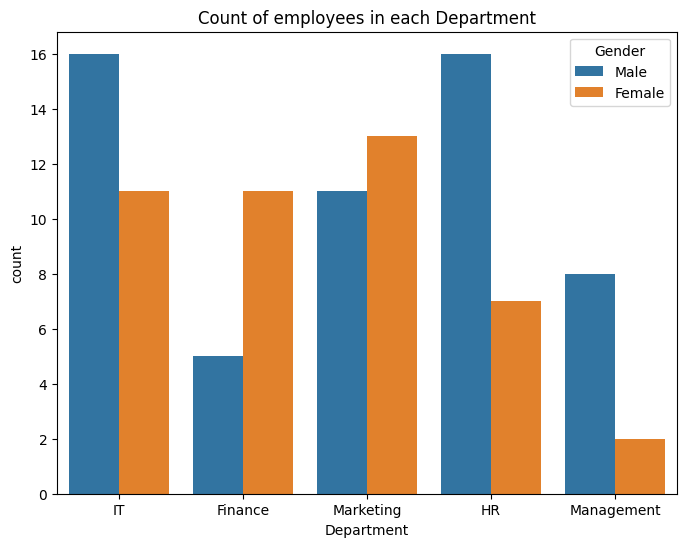

In [49]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Department', hue='Gender')
plt.title("Count of employees in each Department")
plt.show()